In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dataclasses import dataclass

from tqdm import tqdm

import orjson
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm, trange

from sae_java_bug.logger import logger
from sae_java_bug.sparse_autoencoders.utils import get_device

from typing import List
from collections import defaultdict

@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


/Users/rmelo/miniconda3/envs/demeanor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import glob
import orjson
import torch
from tqdm import tqdm
from sae_java_bug.sparse_autoencoders.sae_exploration import ActivationsSchema

from sae_java_bug.logger import logger
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import Dict, Tuple
from sklearn.model_selection import KFold

class MLP(nn.Module):
    def __init__(
        self, input_dim, output_dim=2, hidden=(128, 64), dropout=0.3, use_bn=True
    ):
        super().__init__()
        h1, h2 = hidden
        self.use_bn = use_bn

        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1) if use_bn else nn.Identity()
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2) if use_bn else nn.Identity()
        self.fc3 = nn.Linear(h2, output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc3(x)  # logits
        return x

def evaluate(loader, model, device=get_device(verbose=False)):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    y_true = torch.cat(all_labels)
    y_pred = torch.cat(all_preds)
    return accuracy_score(y_true, y_pred), y_true, y_pred

def train_small_mlp_kfold(class_negative: torch.Tensor, class_positive: torch.Tensor, k=5):

    # Create labels
    vuln_labels = torch.ones(class_positive.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(class_negative.size(0), dtype=torch.float32)

    all_features = torch.cat((class_positive, class_negative), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # print("All Features Shape:", all_features.shape)
    # print("All Labels Shape:", all_labels.shape)

    dataset = TensorDataset(all_features, all_labels)

    # Initialize KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold = 1
    fold_acc = []

    for train_idx, test_idx in kf.split(all_features):

        # print(f"\n===== Fold {fold}/{k} =====")
        fold += 1

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset  = torch.utils.data.Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, drop_last=True)
        test_loader  = DataLoader(test_subset, batch_size=1000, shuffle=False, drop_last=False)

        # new model per fold
        model = MLP(input_dim=all_features.size(1)).to(device)
        # activate gradients
        model.train()
        torch.set_grad_enabled(True)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        num_epochs = 50  # often fewer needed

        for epoch in range(num_epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits = model(x_batch)
                loss = F.cross_entropy(logits, y_batch)
                loss.backward()
                optimizer.step()

        # evaluate this fold
        acc, _, _ = evaluate(test_loader, model, device)
        fold_acc.append(acc)

    #     print(f"Fold Test Accuracy: {acc:.4f}")

    # print("\n===== K-Fold Results =====")
    # print(f"Fold Accuracies: {fold_acc}")
    # print(f"Mean Accuracy: {sum(fold_acc)/len(fold_acc):.4f}")

    return sum(fold_acc)/len(fold_acc)


device = get_device(verbose=True)

layer_scores = {}
RUN_ID = "run_20260127_044329"
RUN_ID = "run_20260127_195450" # this is the swapped operands activations
RUN_ID = "run_20260127_202722" # this is the cwes data
RUN_ID = "run_20260128_184854" # Trained with DeltaSeccommits
RUN_ID = "run_20260131_190935_rufimelo_secure_code_qwen_coder_strd_16384"
RUN_ID = "run_20260202_220441_rufimelo_secure_code_qwen_coder_topk_16384"
RUN_ID = "run_20260204_050125_rufimelo_secure_code_qwen_coder_strd_16384_raw"

@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


def compute_lda_fisher_scores(secure_features: torch.Tensor, vulnerable_features: torch.Tensor) -> float:
    # Create labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA — build dataset for layer
    X = all_features.numpy()
    y = all_labels.numpy()

    # Train LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(X, y)

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    mean_diff = vuln_proj.mean() - safe_proj.mean()
    var_sum = vuln_proj.var() + safe_proj.var()
    fisher_score = (mean_diff ** 2) / (var_sum + 1e-8)

    return float(fisher_score)
def process_files(
    files
):
    FisherScoreMap: Dict[Tuple[str, str], float] = {}
    ProbingDataMap: Dict[Tuple[str, str], float] = {}

    all_vulnerable_features: Dict[str, List[float]] = defaultdict(list)
    all_safe_features : Dict[str, List[float]] = defaultdict(list)

    for activation_file in files:
        logger.info("Processing file.", file=activation_file)

        cwe_tensor_map: Dict[str, VulnerabilityData] = {}
        vulnerable_features = torch.tensor([])
        safe_features = torch.tensor([])
        
        # Loads activations.
        with open(activation_file, "r") as f: 
            for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
                try:
                    data = orjson.loads(line)
                except orjson.JSONDecodeError as e:
                    logger.error(f"JSON decoding error: {e}")
                    # skip to the next file
                    break
                
                cwe = data["cwe"]
                if cwe not in cwe_tensor_map:
                    cwe_tensor_map[cwe] = VulnerabilityData(
                        vulnerable=torch.tensor([]),
                        secure=torch.tensor([]),
                    )

                activations = ActivationsSchema(**data)
                vuln_tensor = torch.tensor(activations.vulnerable)
                safe_tensor = torch.tensor(activations.secure)


                vulnerable_features = torch.cat(
                    (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
                )
                safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)
                

                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.cat(
                        (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                    ),
                    secure=torch.cat(
                        (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                    ),
                )

            print("Vulnerable Features Shape:", vulnerable_features.shape , "Safe Features Shape:", safe_features.shape)
            print("CWE:", cwe, "Vulnerable Shape:", vulnerable_features.shape, "Safe Shape:", safe_features.shape)
        
            all_vulnerable_features[
                "layer_" + activation_file.split("layer_")[1].split("_")[0]
            ] = torch.tensor(vulnerable_features)
            all_safe_features[
                "layer_" + activation_file.split("layer_")[1].split("_")[0]
            ]= torch.tensor(safe_features)
            

        # Save for later reuse
        layer_id = activation_file.split("layer_")[1].split("_")[0]
        torch.save(vulnerable_features, f"../artifacts/activations/{RUN_ID}/vulnerable_layer_{layer_id}.pt")
        torch.save(safe_features, f"../artifacts/activations/{RUN_ID}/safe_layer_{layer_id}.pt")

    return FisherScoreMap, ProbingDataMap, all_vulnerable_features, all_safe_features



2026-02-04 17:10:04 [info     ] Getting device.                device=mps


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /datasets/rufimelo/DeltaSecommits/resolve/main/README.md (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x19ee49490>: Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: a611276c-cc05-4cac-a9b2-942ec777953e)')' thrown while requesting HEAD https://huggingface.co/datasets/rufimelo/DeltaSecommits/resolve/main/README.md
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /datasets/rufimelo/DeltaSecommits/resolve/main/README.md (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x19f195ee0>: Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 5d3b7e05-1f4d-4ce2-8e07-b91759e8e9ba)')' thrown while requesting HEAD https://huggingface

2026-02-04 17:10:31 [info     ] Getting device.                device=mps


In [4]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"), key=lambda x: int(x.split("layer_")[1].split("_")[0]))

FisherScoreMap, ProbingDataMap, all_vulnerable_features, all_safe_features = process_files(
    files
)

2026-02-04 17:10:36 [info     ] Processing file.               file=../artifacts/activations/run_20260204_050125_rufimelo_secure_code_qwen_coder_strd_16384_raw/activations_layer_0_raw_component_hidden_state_last_token.jsonl


Loading: 100%|█████████▉| 2493/2500 [00:41<00:00, 60.33 lines/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1455146990.py:221: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)


Vulnerable Features Shape: torch.Size([2493, 3584]) Safe Features Shape: torch.Size([2493, 3584])
CWE: CWE-787 Vulnerable Shape: torch.Size([2493, 3584]) Safe Shape: torch.Size([2493, 3584])
2026-02-04 17:11:17 [info     ] Processing file.               file=../artifacts/activations/run_20260204_050125_rufimelo_secure_code_qwen_coder_strd_16384_raw/activations_layer_14_raw_component_hidden_state_last_token.jsonl


/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1455146990.py:224: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)
Loading: 100%|█████████▉| 2493/2500 [00:41<00:00, 60.60 lines/s]


Vulnerable Features Shape: torch.Size([2493, 3584]) Safe Features Shape: torch.Size([2493, 3584])
CWE: CWE-787 Vulnerable Shape: torch.Size([2493, 3584]) Safe Shape: torch.Size([2493, 3584])
2026-02-04 17:11:58 [info     ] Processing file.               file=../artifacts/activations/run_20260204_050125_rufimelo_secure_code_qwen_coder_strd_16384_raw/activations_layer_27_raw_component_hidden_state_last_token.jsonl


Loading: 100%|█████████▉| 2493/2500 [00:40<00:00, 61.22 lines/s]


Vulnerable Features Shape: torch.Size([2493, 3584]) Safe Features Shape: torch.Size([2493, 3584])
CWE: CWE-787 Vulnerable Shape: torch.Size([2493, 3584]) Safe Shape: torch.Size([2493, 3584])


In [5]:
# for key, data in tqdm(cwe_tensor_map.items()):
#     try:
#         # fisher_score = compute_lda_fisher_scores(data.secure, data.vulnerable)
#         # FisherScoreMap[(layer_id, key)] = fisher_score
#         probe_score = train_small_mlp_kfold(data.secure, data.vulnerable, k=5)
#         ProbingDataMap[(layer_id, key)] = probe_score
#     except Exception as e:
#         logger.error(f"Error processing CWE {key} in layer {layer_id}: {e}")


# # fisher_score = compute_lda_fisher_scores(safe_features, vulnerable_features)
# # FisherScoreMap[(layer_id, "ALL")] = fisher_score
# probe_score = train_small_mlp_kfold(safe_features, vulnerable_features, k=5)
# ProbingDataMap[(layer_id, "ALL")] = probe_score

In [6]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"))

def get_data(files: list, layer_id: int, cwe: str):
    # Read file and extract data for given layer_id and cwe
    for file in files:
        if f"layer_{layer_id}_" in file:
            activation_file = file
            break
    else:
        raise ValueError(f"Layer {layer_id} not found in files.")
    

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    # Loads activations.
    with open(activation_file, "r") as f:
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            _cwe = data["cwe"]
            if _cwe != cwe:
                continue
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            # print(f"Vuln ID: {activations.vuln_id}, Layer: {activations.layer}")
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)



            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )


    return cwe_tensor_map[cwe]


def plot_pca(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # PCA
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("PCA of Activations")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lda(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(all_features.numpy(), all_labels.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.hist(vuln_proj, bins=30, alpha=0.5, label=label_vulnerable, color="r")
    plt.hist(safe_proj, bins=30, alpha=0.5, label=label_secure, color="g")
    plt.title("LDA of Activations")
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()


def plot_tsne(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    proj = tsne.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("t-SNE of Activations")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.grid()
    plt.show()

# Paper Plan

## Per-sample mean latent activation

In [8]:
from dataclasses import dataclass
from typing import Optional, Tuple
from enum import Enum
import pickle
from tqdm import tqdm
import numpy as np
import torch
import matplotlib.pyplot as plt


class FeatureType(Enum):
    """Classification based on activation frequency p_i = P(z_i > ε)."""
    ACTIVE = "active"      # p_i >= 10%: fires often, model with range
    DORMANT = "dormant"    # p_i < 10%: rarely fires, flag any activation


@dataclass
class FeatureInvariant:
    """Invariant for a single SAE feature."""
    feature_idx: int
    feature_type: FeatureType
    activation_freq: float  # p_i = P(z_i > ε) on secure data
    
    # For ACTIVE features: range statistics
    median: Optional[float] = None
    mad: Optional[float] = None
    q1: Optional[float] = None
    q3: Optional[float] = None
    iqr: Optional[float] = None
    
    # For DORMANT features: activation threshold
    activation_threshold: float = 0.0  # θ_i: 99.9th percentile of secure activations
    
    def is_range_violation(self, value: float, k: float = 3.0) -> bool:
        """
        Check if value violates the range invariant (ACTIVE features only).
        Returns False for DORMANT features.
        """
        if self.feature_type != FeatureType.ACTIVE:
            return False
        if self.mad is None or self.mad == 0:
            return False
        lower = self.median - k * self.mad
        upper = self.median + k * self.mad
        return value < lower or value > upper
    
    def is_activation_violation(self, value: float) -> bool:
        """
        Check if value violates the dormancy invariant (DORMANT features only).
        Returns True if a dormant feature fires above its threshold.
        """
        if self.feature_type != FeatureType.DORMANT:
            return False
        return value > self.activation_threshold
    
    def range_violation_score(self, value: float) -> float:
        """
        Compute |z - median| / MAD for ACTIVE features.
        Returns 0 for DORMANT features.
        """
        if self.feature_type != FeatureType.ACTIVE:
            return 0.0
        if self.mad is None or self.mad == 0:
            return 0.0
        return abs(value - self.median) / self.mad


def compute_mad(values: np.ndarray) -> float:
    """Compute Median Absolute Deviation."""
    median = np.median(values)
    return np.median(np.abs(values - median))


def compute_feature_invariants(
    secure_activations: torch.Tensor,
    activation_freq_threshold: float = 0.10,  # 10% threshold
    noise_epsilon: float = 1e-6,
    dormant_percentile: float = 99.9,
) -> list[FeatureInvariant]:
    """
    Compute feature invariants based on secure code activations.
    
    Step A: Classify by activation frequency p_i = P(z_i > ε)
    Step B: Compute appropriate statistics for each type
    
    Args:
        secure_activations: Tensor of shape (n_samples, n_features)
        activation_freq_threshold: Features with p_i >= this are ACTIVE
        noise_epsilon: Threshold for "active" (non-zero) activation
        dormant_percentile: Percentile for dormant activation threshold
    """
    secure_np = secure_activations.numpy()
    n_samples, n_features = secure_np.shape
    
    invariants = []
    
    print(f"Computing feature invariants for {n_features} features...")
    print(f"  Activation frequency threshold: {activation_freq_threshold*100:.0f}%")
    print(f"  Noise epsilon: {noise_epsilon}")
    print(f"  Dormant threshold percentile: {dormant_percentile}")
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_values = secure_np[:, i]
        
        # Step A: Compute activation frequency p_i = P(z_i > ε)
        activation_freq = (feature_values > noise_epsilon).sum() / n_samples
        
        # Classify feature
        if activation_freq >= activation_freq_threshold:
            feature_type = FeatureType.ACTIVE
        else:
            feature_type = FeatureType.DORMANT
        
        # Step B: Compute type-specific statistics
        if feature_type == FeatureType.ACTIVE:
            # Active features: compute range statistics on all values
            median = np.median(feature_values)
            mad = compute_mad(feature_values)
            q1 = np.percentile(feature_values, 25)
            q3 = np.percentile(feature_values, 75)
            iqr = q3 - q1
            activation_threshold = 0.0  # Not used for active features
            
            invariants.append(FeatureInvariant(
                feature_idx=i,
                feature_type=feature_type,
                activation_freq=activation_freq,
                median=median,
                mad=mad,
                q1=q1,
                q3=q3,
                iqr=iqr,
                activation_threshold=activation_threshold,
            ))
        else:
            # Dormant features: compute activation threshold θ_i
            # Use high percentile (99.9%) of all values as threshold
            activation_threshold = np.percentile(feature_values, dormant_percentile)
            
            invariants.append(FeatureInvariant(
                feature_idx=i,
                feature_type=feature_type,
                activation_freq=activation_freq,
                activation_threshold=activation_threshold,
            ))
    
    return invariants


@dataclass
class SampleViolationScores:
    """Violation scores for a single sample."""
    # Active feature violations
    range_violation_score: float  # Sum of |z - median| / MAD for active features
    range_violation_count: int    # Number of active features outside k*MAD
    n_active_features: int
    
    # Dormant feature violations
    activation_violation_count: int  # Number of dormant features that fired
    n_dormant_features: int
    
    # Per-feature details (for analysis)
    active_violations: list[int] = None    # Indices of violated active features
    dormant_violations: list[int] = None   # Indices of violated dormant features


def compute_sample_violations(
    sample: np.ndarray,
    invariants: list[FeatureInvariant],
    k: float = 3.0,
) -> SampleViolationScores:
    """
    Compute violation scores for a single sample.
    
    Args:
        sample: 1D array of activations
        invariants: List of FeatureInvariant objects
        k: MAD multiplier for range violations
    """
    range_violation_score = 0.0
    range_violation_count = 0
    activation_violation_count = 0
    
    n_active = 0
    n_dormant = 0
    
    active_violations = []
    dormant_violations = []
    
    for inv in invariants:
        value = sample[inv.feature_idx]
        
        if inv.feature_type == FeatureType.ACTIVE:
            n_active += 1
            # Compute range violation score
            score = inv.range_violation_score(value)
            range_violation_score += score
            
            # Check if it's a violation (outside k*MAD)
            if inv.is_range_violation(value, k):
                range_violation_count += 1
                active_violations.append(inv.feature_idx)
        
        else:  # DORMANT
            n_dormant += 1
            # Check if dormant feature activated
            if inv.is_activation_violation(value):
                activation_violation_count += 1
                dormant_violations.append(inv.feature_idx)
    
    return SampleViolationScores(
        range_violation_score=range_violation_score,
        range_violation_count=range_violation_count,
        n_active_features=n_active,
        activation_violation_count=activation_violation_count,
        n_dormant_features=n_dormant,
        active_violations=active_violations,
        dormant_violations=dormant_violations,
    )


def analyze_population(
    activations: torch.Tensor,
    invariants: list[FeatureInvariant],
    k: float = 3.0,
    label: str = "Population",
) -> list[SampleViolationScores]:
    """Compute violation scores for all samples in a population."""
    act_np = activations.numpy()
    scores = []
    
    for sample in tqdm(act_np, desc=f"Analyzing {label}"):
        scores.append(compute_sample_violations(sample, invariants, k))
    
    return scores



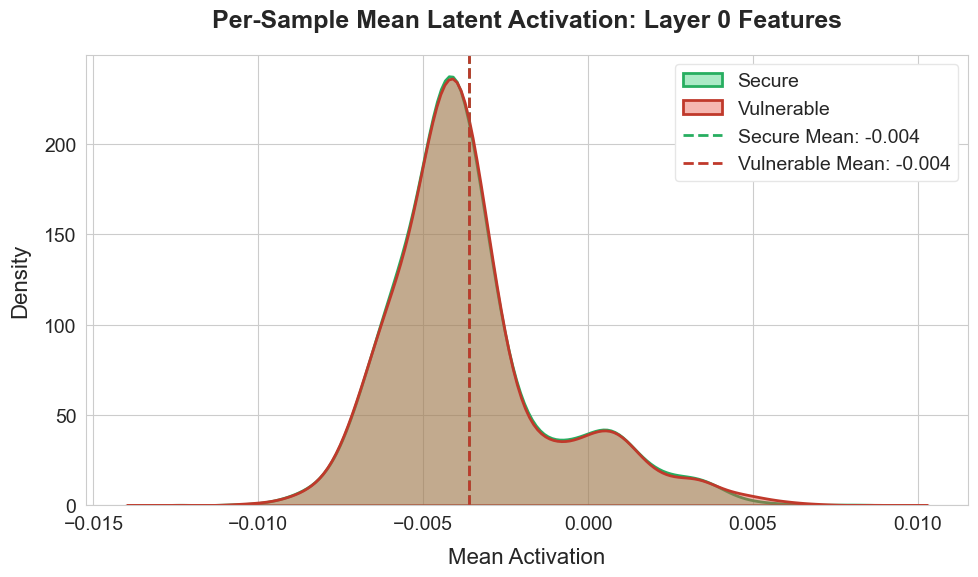

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from matplotlib import rcParams

# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})

def plot_mean_activations_kde(
    secure_activations: torch.Tensor,
    vulnerable_activations: torch.Tensor,
    layer_name: str = "Layer 0",
):
    secure_means = secure_activations.mean(dim=1).numpy()
    vulnerable_means = vulnerable_activations.mean(dim=1).numpy()

    # Calculate statistics for annotations
    secure_mean = np.mean(secure_means)
    vulnerable_mean = np.mean(vulnerable_means)
    secure_std = np.std(secure_means)
    vulnerable_std = np.std(vulnerable_means)

    # Create figure
    plt.figure(figsize=(10, 6), dpi=100)
    sns.set_style("whitegrid")

    # Plot KDEs with refined styling
    ax = sns.kdeplot(
        secure_means,
        label="Secure",
        fill=True,
        alpha=0.4,
        color="#2ecc71",  # Vibrant green
        linewidth=2,
        edgecolor="#27ae60",  # Darker green for edge
    )
    sns.kdeplot(
        vulnerable_means,
        label="Vulnerable",
        fill=True,
        alpha=0.4,
        color="#e74c3c",  # Vibrant red
        linewidth=2,
        edgecolor="#c0392b",  # Darker red for edge
    )

    # Add vertical lines for means with improved styling
    plt.axvline(
        secure_mean,
        color="#27ae60",
        linestyle="--",
        linewidth=2,
        label=f"Secure Mean: {secure_mean:.3f}",
    )
    plt.axvline(
        vulnerable_mean,
        color="#c0392b",
        linestyle="--",
        linewidth=2,
        label=f"Vulnerable Mean: {vulnerable_mean:.3f}",
    )

    # Add annotations for standard deviations
    plt.text(
        secure_mean + 0.01,
        0.9 * ax.get_ylim()[1],
        f"σ = {secure_std:.3f}",
        color="#27ae60",
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )
    plt.text(
        vulnerable_mean + 0.01,
        0.8 * ax.get_ylim()[1],
        f"σ = {vulnerable_std:.3f}",
        color="#c0392b",
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )

    # Labels and title
    plt.title(
        f"Per-Sample Mean Latent Activation: {layer_name}",
        pad=20,
        fontsize=18,
        weight="bold",
    )
    plt.xlabel("Mean Activation", labelpad=10)
    plt.ylabel("Density", labelpad=10)

    # Legend with refined positioning
    plt.legend(
        loc="upper right",
        frameon=True,
        framealpha=1,
        facecolor="white",
        edgecolor="0.9",
        fancybox=True,
    )

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(f"mean_activations_{layer_name.replace(' ', '_')}.pdf", bbox_inches="tight", format="pdf")
    plt.show()

# Example usage
secure_activations = all_safe_features["layer_0"]
vulnerable_activations = all_vulnerable_features["layer_0"]
plot_mean_activations_kde(secure_activations, vulnerable_activations, layer_name="Layer 0 Features")


## L2 norm of latent vectors for both classes.

<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1693798106.py:85: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1693798106.py:87: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)


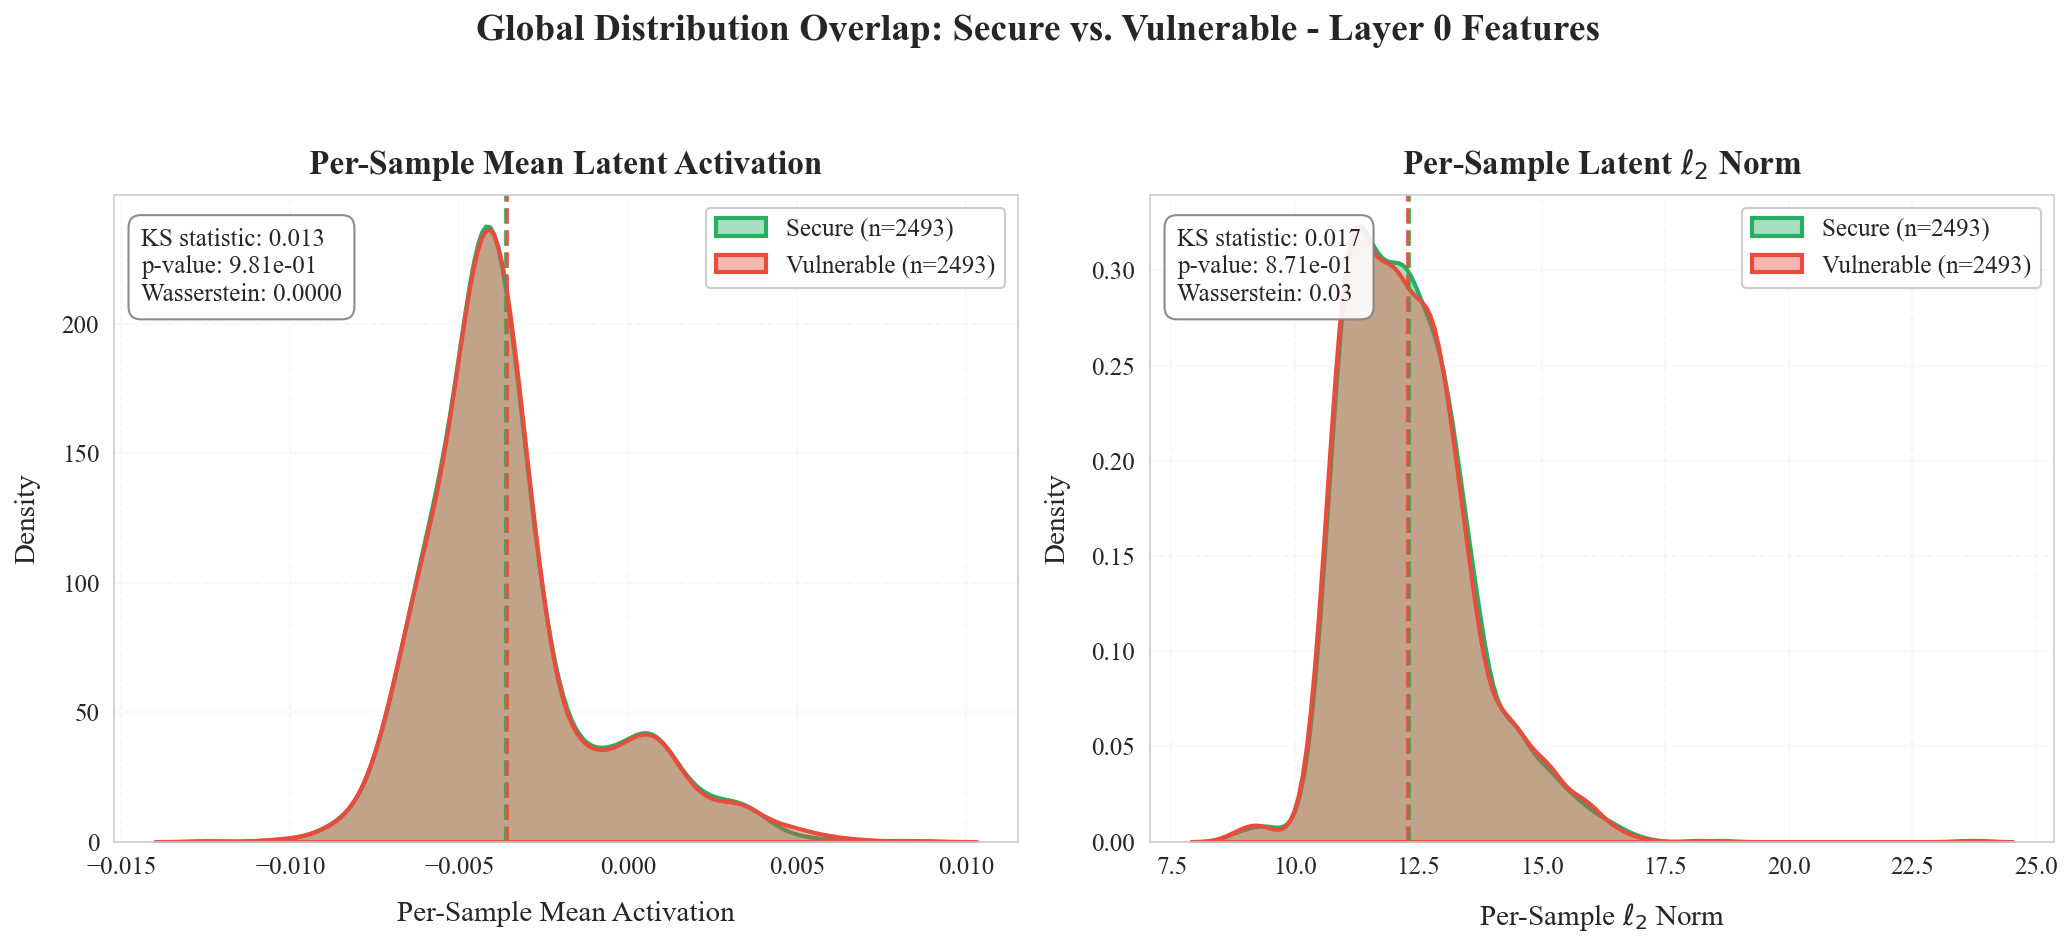


CLAIM: Vulnerable code does not form a globally anomalous population

Per-Sample Mean Activation:
  Secure:     μ = -0.003624 ± 0.002504
  Vulnerable: μ = -0.003597 ± 0.002560
  Overlap:    KS = 0.013, p = 9.81e-01
             Wasserstein distance = 0.0000

Per-Sample L2 Norm:
  Secure:     μ = 12.30 ± 1.28
  Vulnerable: μ = 12.29 ± 1.29
  Overlap:    KS = 0.017, p = 8.71e-01
             Wasserstein distance = 0.03

→ Conclusion: Distributions overlap heavily, explaining why PCA fails.


In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from matplotlib import rcParams

# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})

def plot_global_distribution_overlap(secure_activations, vulnerable_activations, layer_name="Layer 0"):
    # Convert to numpy
    secure_np = secure_activations.numpy()
    vuln_np = vulnerable_activations.numpy()

    # Compute per-sample statistics
    secure_mean_activation = np.mean(secure_np, axis=1)
    vuln_mean_activation = np.mean(vuln_np, axis=1)
    secure_l2_norm = np.linalg.norm(secure_np, axis=1)
    vuln_l2_norm = np.linalg.norm(vuln_np, axis=1)

    # Create figure with improved layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    fig.suptitle(f'Global Distribution Overlap: Secure vs. Vulnerable - {layer_name}',
                fontsize=18, fontweight='bold', y=1.05)

    # Panel 1: Per-Sample Mean Latent Activation
    ax = axes[0]
    sns.kdeplot(secure_mean_activation, ax=ax, color='#27AE60', fill=True, alpha=0.4,
                label=f'Secure (n={len(secure_mean_activation)})', linewidth=2)
    sns.kdeplot(vuln_mean_activation, ax=ax, color='#E74C3C', fill=True, alpha=0.4,
                label=f'Vulnerable (n={len(vuln_mean_activation)})', linewidth=2)

    # Add vertical lines for means
    ax.axvline(np.mean(secure_mean_activation), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(np.mean(vuln_mean_activation), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

    # Compute overlap statistics
    ks_stat, ks_pval = ks_2samp(secure_mean_activation, vuln_mean_activation)
    ws_dist = wasserstein_distance(secure_mean_activation, vuln_mean_activation)

    ax.set_xlabel('Per-Sample Mean Activation', fontsize=14, labelpad=10)
    ax.set_ylabel('Density', fontsize=14, labelpad=10)
    ax.set_title('Per-Sample Mean Latent Activation', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='upper right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation with improved formatting
    stats_text = (f'KS statistic: {ks_stat:.3f}\n'
                 f'p-value: {ks_pval:.2e}\n'
                 f'Wasserstein: {ws_dist:.4f}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Panel 2: Per-Sample L2 Norm
    ax = axes[1]
    sns.kdeplot(secure_l2_norm, ax=ax, color='#27AE60', fill=True, alpha=0.4,
                label=f'Secure (n={len(secure_l2_norm)})', linewidth=2)
    sns.kdeplot(vuln_l2_norm, ax=ax, color='#E74C3C', fill=True, alpha=0.4,
                label=f'Vulnerable (n={len(vuln_l2_norm)})', linewidth=2)

    # Add vertical lines for means
    ax.axvline(np.mean(secure_l2_norm), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(np.mean(vuln_l2_norm), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

    # Compute overlap statistics
    ks_stat_l2, ks_pval_l2 = ks_2samp(secure_l2_norm, vuln_l2_norm)
    ws_dist_l2 = wasserstein_distance(secure_l2_norm, vuln_l2_norm)

    ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
    ax.set_ylabel('Density', fontsize=14, labelpad=10)
    ax.set_title('Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='upper right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation
    stats_text = (f'KS statistic: {ks_stat_l2:.3f}\n'
                 f'p-value: {ks_pval_l2:.2e}\n'
                 f'Wasserstein: {ws_dist_l2:.2f}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Adjust layout
    plt.tight_layout()

    # # Add interpretation text below with improved styling
    # interpretation = ('⚠ Key Insight: Vulnerable code does NOT form a globally anomalous population.\n'
    #                  'The distributions overlap significantly → PCA/global outlier detection will fail.')
    # fig.text(0.5, 0.01, interpretation,
    #          ha='center', fontsize=14, style='italic',
    #          bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9E6', alpha=0.9, edgecolor='#E0E0E0'))

    # Save and show

    plt.savefig(f"global_distribution_overlap_{layer_name.replace(' ', '_')}.pdf", bbox_inches="tight", format="pdf")
    plt.show()

    # Print summary with improved formatting
    print(f"\n{'='*80}")
    print("CLAIM: Vulnerable code does not form a globally anomalous population")
    print(f"{'='*80}")
    print(f"\nPer-Sample Mean Activation:")
    print(f"  Secure:     μ = {np.mean(secure_mean_activation):.6f} ± {np.std(secure_mean_activation):.6f}")
    print(f"  Vulnerable: μ = {np.mean(vuln_mean_activation):.6f} ± {np.std(vuln_mean_activation):.6f}")
    print(f"  Overlap:    KS = {ks_stat:.3f}, p = {ks_pval:.2e}")
    print(f"             Wasserstein distance = {ws_dist:.4f}")

    print(f"\nPer-Sample L2 Norm:")
    print(f"  Secure:     μ = {np.mean(secure_l2_norm):.2f} ± {np.std(secure_l2_norm):.2f}")
    print(f"  Vulnerable: μ = {np.mean(vuln_l2_norm):.2f} ± {np.std(vuln_l2_norm):.2f}")
    print(f"  Overlap:    KS = {ks_stat_l2:.3f}, p = {ks_pval_l2:.2e}")
    print(f"             Wasserstein distance = {ws_dist_l2:.2f}")

    print(f"\n→ Conclusion: Distributions overlap heavily, explaining why PCA fails.")
    print(f"{'='*80}")

# Example usage
plot_global_distribution_overlap(secure_activations, vulnerable_activations, layer_name="Layer 0 Features")


<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:96: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:96: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/2058623306.py:94: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/2058623306.py:96: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('CDF: Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)


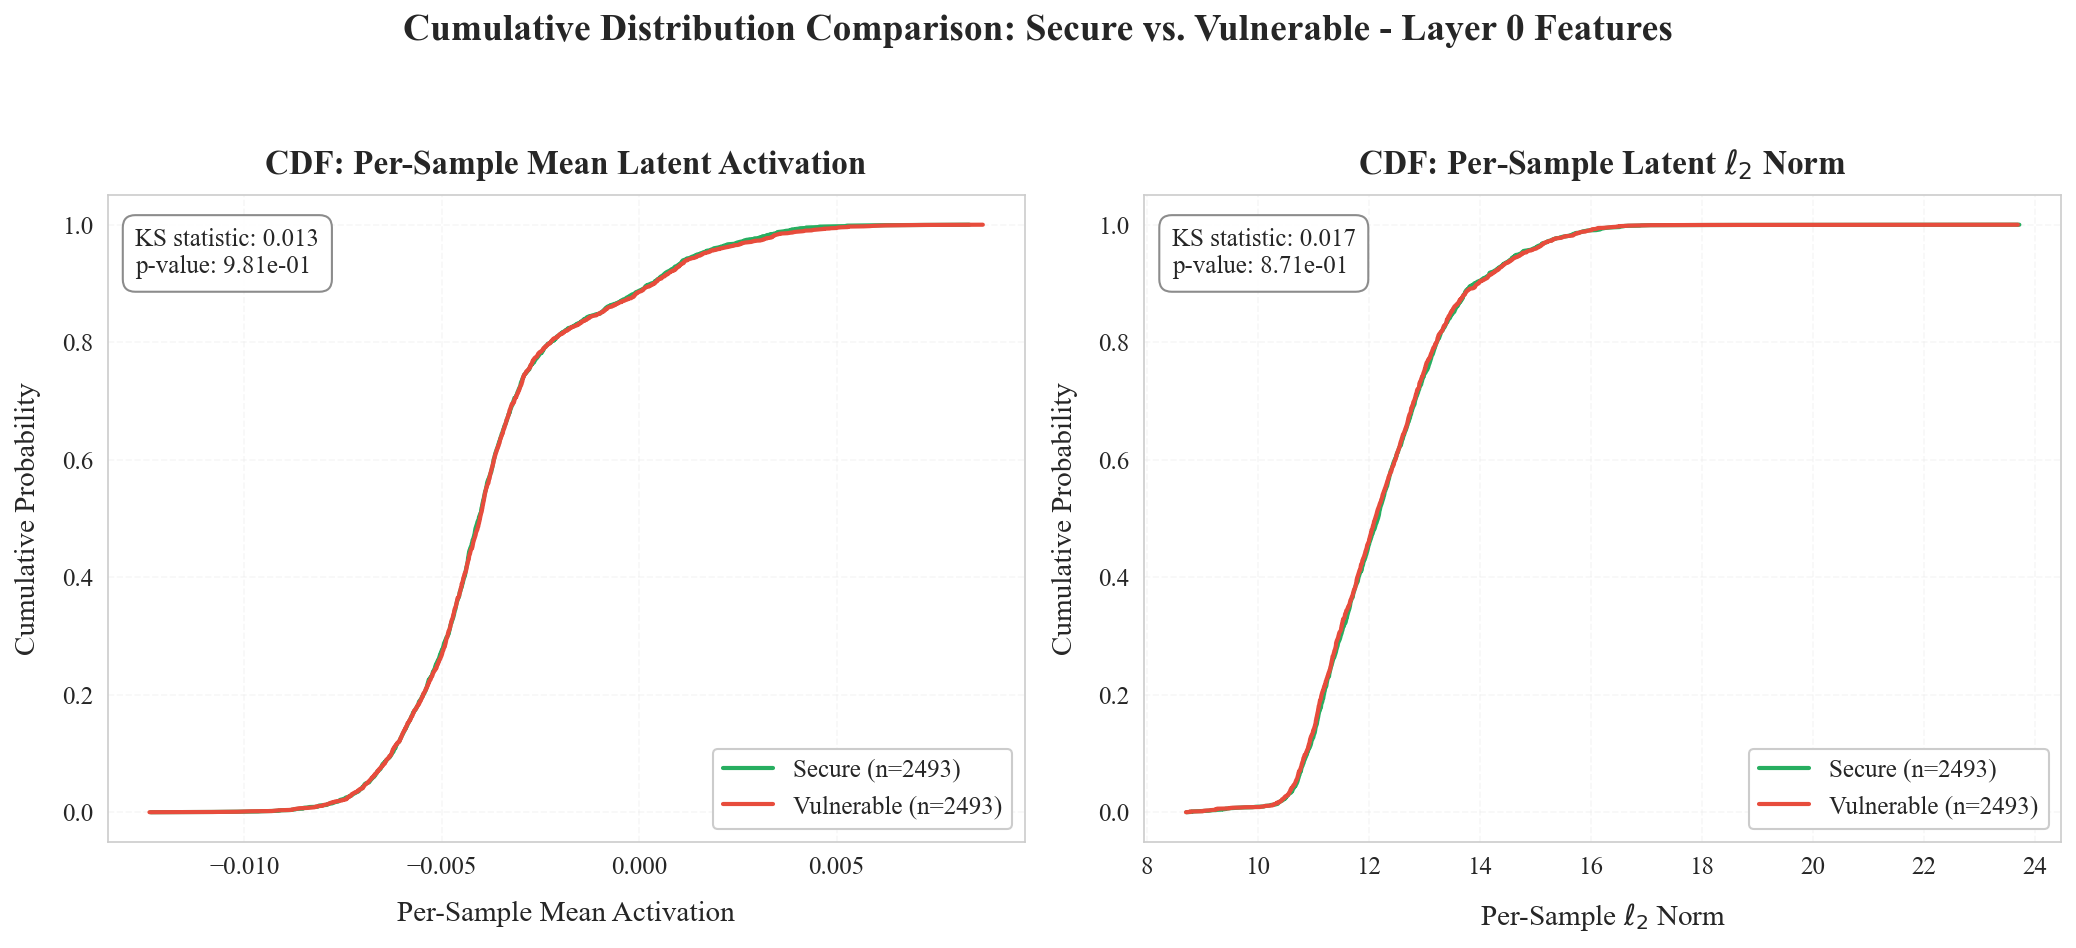


CLAIM: Vulnerable code cumulative distributions overlap heavily with secure code

Per-Sample Mean Activation KS Test:
  KS statistic: 0.013
  p-value: 9.81e-01

Per-Sample L2 Norm KS Test:
  KS statistic: 0.017
  p-value: 8.71e-01

→ Conclusion: CDFs are nearly identical, confirming no global separation.


In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from matplotlib import rcParams

# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})

def plot_cumulative_distribution(
    secure_activations: torch.Tensor,
    vulnerable_activations: torch.Tensor,
    layer_name: str = "Layer 0 Features"
):
    # Convert to numpy
    secure_np = secure_activations.numpy()
    vuln_np = vulnerable_activations.numpy()

    # Compute per-sample statistics
    secure_mean_activation = np.mean(secure_np, axis=1)
    vuln_mean_activation = np.mean(vuln_np, axis=1)
    secure_l2_norm = np.linalg.norm(secure_np, axis=1)
    vuln_l2_norm = np.linalg.norm(vuln_np, axis=1)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    fig.suptitle(f'Cumulative Distribution Comparison: Secure vs. Vulnerable - {layer_name}',
                fontsize=18, fontweight='bold', y=1.05)

    # Panel 1: CDF of Mean Activations
    ax = axes[0]

    # Sort the data for CDF
    sorted_secure = np.sort(secure_mean_activation)
    sorted_vuln = np.sort(vuln_mean_activation)

    # Calculate CDF values
    cdf_secure = np.arange(1, len(sorted_secure) + 1) / len(sorted_secure)
    cdf_vuln = np.arange(1, len(sorted_vuln) + 1) / len(sorted_vuln)

    # Plot CDFs
    ax.plot(sorted_secure, cdf_secure, color='#27AE60', linewidth=2, label=f'Secure (n={len(sorted_secure)})')
    ax.plot(sorted_vuln, cdf_vuln, color='#E74C3C', linewidth=2, label=f'Vulnerable (n={len(sorted_vuln)})')

    # Compute overlap statistics
    ks_stat, ks_pval = ks_2samp(secure_mean_activation, vuln_mean_activation)

    ax.set_xlabel('Per-Sample Mean Activation', fontsize=14, labelpad=10)
    ax.set_ylabel('Cumulative Probability', fontsize=14, labelpad=10)
    ax.set_title('CDF: Per-Sample Mean Latent Activation', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation
    stats_text = (f'KS statistic: {ks_stat:.3f}\n'
                 f'p-value: {ks_pval:.2e}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Panel 2: CDF of L2 Norms
    ax = axes[1]

    # Sort the data for CDF
    sorted_secure_l2 = np.sort(secure_l2_norm)
    sorted_vuln_l2 = np.sort(vuln_l2_norm)

    # Calculate CDF values
    cdf_secure_l2 = np.arange(1, len(sorted_secure_l2) + 1) / len(sorted_secure_l2)
    cdf_vuln_l2 = np.arange(1, len(sorted_vuln_l2) + 1) / len(sorted_vuln_l2)

    # Plot CDFs
    ax.plot(sorted_secure_l2, cdf_secure_l2, color='#27AE60', linewidth=2, label=f'Secure (n={len(sorted_secure_l2)})')
    ax.plot(sorted_vuln_l2, cdf_vuln_l2, color='#E74C3C', linewidth=2, label=f'Vulnerable (n={len(sorted_vuln_l2)})')

    # Compute overlap statistics
    ks_stat_l2, ks_pval_l2 = ks_2samp(secure_l2_norm, vuln_l2_norm)

    ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
    ax.set_ylabel('Cumulative Probability', fontsize=14, labelpad=10)
    ax.set_title('CDF: Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation
    stats_text = (f'KS statistic: {ks_stat_l2:.3f}\n'
                 f'p-value: {ks_pval_l2:.2e}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Adjust layout
    plt.tight_layout()

    # Add interpretation text below with improved styling
    # interpretation = ('⚠ Key Insight: The cumulative distributions are nearly identical,\n'
    #                  'confirming that vulnerable code does NOT form a globally separable population.')
    # fig.text(0.5, 0.01, interpretation,
    #          ha='center', fontsize=14, style='italic',
    #          bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9E6', alpha=0.9, edgecolor='#E0E0E0'))

    # Save and show
    plt.savefig(f"cumulative_distribution_{layer_name.replace(' ', '_')}.pdf", bbox_inches="tight", format="pdf")
    plt.show()

    # Print summary
    print(f"\n{'='*80}")
    print("CLAIM: Vulnerable code cumulative distributions overlap heavily with secure code")
    print(f"{'='*80}")
    print(f"\nPer-Sample Mean Activation KS Test:")
    print(f"  KS statistic: {ks_stat:.3f}")
    print(f"  p-value: {ks_pval:.2e}")

    print(f"\nPer-Sample L2 Norm KS Test:")
    print(f"  KS statistic: {ks_stat_l2:.3f}")
    print(f"  p-value: {ks_pval_l2:.2e}")

    print(f"\n→ Conclusion: CDFs are nearly identical, confirming no global separation.")
    print(f"{'='*80}")

# Example usage
plot_cumulative_distribution(secure_activations, vulnerable_activations, layer_name="Layer 0 Features")


## Plot PCA, TSNE and UMAP 
use the same style

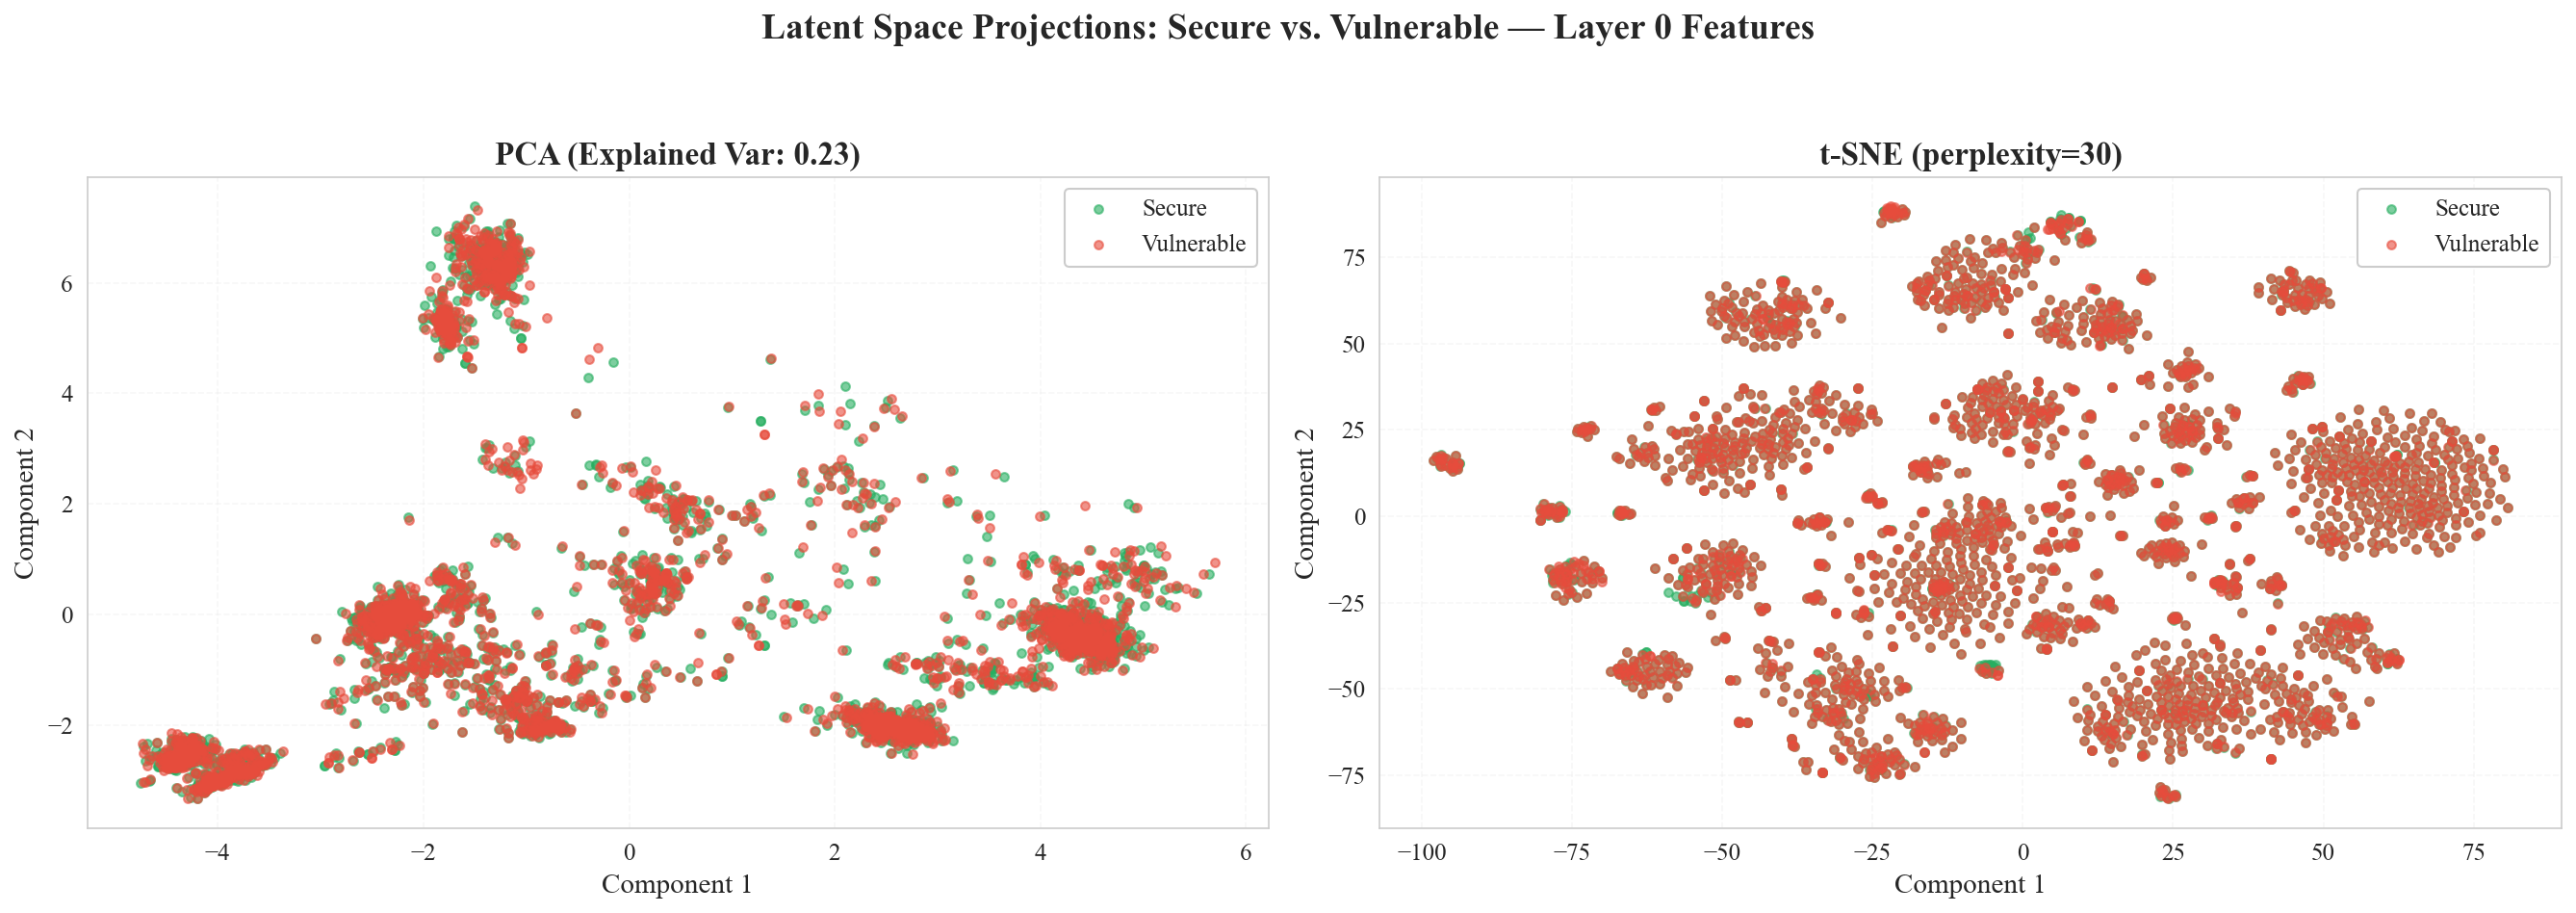


CLAIM: Secure and vulnerable code are not globally separable in latent space
PCA and t-SNE projections show heavy overlap.
→ Any vulnerability signal is likely subtle, local, and context-dependent.


In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from matplotlib import rcParams
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})
def plot_representation_projections(
    secure_activations: torch.Tensor,
    vulnerable_activations: torch.Tensor,
    layer_name: str = "Layer 0 Features",
    tsne_perplexity: int = 30,
    random_state: int = 42
):
    # Convert to numpy
    secure_np = secure_activations.detach().cpu().numpy()
    vuln_np = vulnerable_activations.detach().cpu().numpy()

    # Labels
    X = np.vstack([secure_np, vuln_np])
    y = np.array(
        [0] * len(secure_np) + [1] * len(vuln_np)
    )

    # -----------------------------
    # Dimensionality reductions
    # -----------------------------

    # PCA
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    )
    X_tsne = tsne.fit_transform(X)

    
    # -----------------------------
    # Plotting
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=150)
    fig.suptitle(
        f"Latent Space Projections: Secure vs. Vulnerable — {layer_name}",
        fontsize=18,
        fontweight="bold",
        y=1.05
    )

    def scatter(ax, X_proj, title):
        ax.scatter(
            X_proj[y == 0, 0],
            X_proj[y == 0, 1],
            s=18,
            alpha=0.6,
            color="#27AE60",
            label="Secure"
        )
        ax.scatter(
            X_proj[y == 1, 0],
            X_proj[y == 1, 1],
            s=18,
            alpha=0.6,
            color="#E74C3C",
            label="Vulnerable"
        )
        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_xlabel("Component 1", fontsize=14)
        ax.set_ylabel("Component 2", fontsize=14)
        ax.legend(frameon=True, framealpha=1, facecolor="white")
        ax.grid(True, alpha=0.3)

    scatter(
        axes[0],
        X_pca,
        f"PCA (Explained Var: {pca.explained_variance_ratio_.sum():.2f})"
    )
    scatter(
        axes[1],
        X_tsne,
        f"t-SNE (perplexity={tsne_perplexity})"
    )

    plt.tight_layout()
    plt.savefig(
        f"latent_projections_{layer_name.replace(' ', '_')}.pdf",
        bbox_inches="tight",
        format="pdf"
    )
    plt.show()

    # -----------------------------
    # Interpretation summary
    # -----------------------------
    print(f"\n{'='*80}")
    print("CLAIM: Secure and vulnerable code are not globally separable in latent space")
    print(f"{'='*80}")
    print("PCA and t-SNE projections show heavy overlap.")
    print("→ Any vulnerability signal is likely subtle, local, and context-dependent.")
    print(f"{'='*80}")
plot_representation_projections(
    secure_activations,
    vulnerable_activations,
    layer_name="Layer 0 Features"
)


## Identify Dormant Features

In [13]:
RUN_ID = "run_20260202_220441_rufimelo_secure_code_qwen_coder_topk_16384"

files_SAE = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"), key=lambda x: int(x.split("layer_")[1].split("_")[0]))

FisherScoreMap_SAE, ProbingDataMap_SAE, all_vulnerable_features_SAE, all_safe_features_SAE = process_files(
    files_SAE
)


2026-02-04 17:14:28 [info     ] Processing file.               file=../artifacts/activations/run_20260202_220441_rufimelo_secure_code_qwen_coder_topk_16384/activations_layer_0_sae_blocks.0.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl


Loading: 100%|█████████▉| 2493/2500 [03:21<00:00, 12.37 lines/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1455146990.py:221: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1455146990.py:224: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)


Vulnerable Features Shape: torch.Size([2493, 16384]) Safe Features Shape: torch.Size([2493, 16384])
CWE: CWE-787 Vulnerable Shape: torch.Size([2493, 16384]) Safe Shape: torch.Size([2493, 16384])


In [14]:
secure_activations_sae = all_safe_features_SAE["layer_0"]
vulnerable_activations_sae = all_vulnerable_features_SAE["layer_0"]
invariants = compute_feature_invariants(
    secure_activations=secure_activations_sae,
    activation_freq_threshold=0.10,
    noise_epsilon=1e-6,
    dormant_percentile=99.9,
)
# Total dormant features: 16327 / 16384
print(f"Total dormant features: {sum(1 for inv in invariants if inv.feature_type == FeatureType.DORMANT)} / {len(invariants)}")
# TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES
# Feature  1876: secure= 0.56%, vuln= 1.00%, Δ=+0.44%, ratio=1.8x
dormant_invariants = [inv for inv in invariants if inv.feature_type == FeatureType.DORMANT]
secure_np = secure_activations_sae.numpy()
vuln_np = vulnerable_activations_sae.numpy()
dormant_stats = []
for inv in dormant_invariants:
    feature_values_secure = secure_np[:, inv.feature_idx]
    feature_values_vuln = vuln_np[:, inv.feature_idx]
    secure_freq = (feature_values_secure > 1e-6).sum() / secure_np.shape[0] * 100
    vuln_freq = (feature_values_vuln > 1e-6).sum() / vuln_np.shape[0] * 100
    delta_freq = vuln_freq - secure_freq
    ratio = (vuln_freq / secure_freq) if secure_freq > 0 else float('inf')
    dormant_stats.append((inv.feature_idx, secure_freq, vuln_freq, delta_freq, ratio))
# Sort by delta frequency
dormant_stats.sort(key=lambda x: x[3], reverse=True)
print("TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES")
for stat in dormant_stats[:20]:
    print(f"Feature {stat[0]:5d}: secure={stat[1]:5.2f}%, vuln={stat[2]:5.2f}%, Δ={stat[3]:+5.2f}%, ratio={stat[4]:.1f}x")

Computing feature invariants for 16384 features...
  Activation frequency threshold: 10%
  Noise epsilon: 1e-06
  Dormant threshold percentile: 99.9


Processing features: 100%|██████████| 16384/16384 [00:02<00:00, 6676.88it/s]


Total dormant features: 16190 / 16384
TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES
Feature 15884: secure= 4.65%, vuln= 5.21%, Δ=+0.56%, ratio=1.1x
Feature  7597: secure= 1.44%, vuln= 1.97%, Δ=+0.52%, ratio=1.4x
Feature  7191: secure= 1.76%, vuln= 2.25%, Δ=+0.48%, ratio=1.3x
Feature  9054: secure= 1.76%, vuln= 2.25%, Δ=+0.48%, ratio=1.3x
Feature  1725: secure= 1.64%, vuln= 2.13%, Δ=+0.48%, ratio=1.3x
Feature  7637: secure= 1.81%, vuln= 2.29%, Δ=+0.48%, ratio=1.3x
Feature  8819: secure= 1.64%, vuln= 2.13%, Δ=+0.48%, ratio=1.3x
Feature 10208: secure= 2.21%, vuln= 2.69%, Δ=+0.48%, ratio=1.2x
Feature 11859: secure= 1.81%, vuln= 2.29%, Δ=+0.48%, ratio=1.3x
Feature 12103: secure= 1.72%, vuln= 2.21%, Δ=+0.48%, ratio=1.3x
Feature 16319: secure= 1.72%, vuln= 2.21%, Δ=+0.48%, ratio=1.3x
Feature   491: secure= 1.68%, vuln= 2.17%, Δ=+0.48%, ratio=1.3x
Feature  2613: secure= 1.68%, vuln= 2.17%, Δ=+0.48%, ratio=1.3x
Feature  6016: secure= 1.68%, vuln= 2.17%, Δ=+0.48%, ratio=1.3x
Feature  8005:

In [15]:
from scipy.stats import mannwhitneyu
# Show for the first 10 dormant features they are not significant
for inv in dormant_stats[:10]:
    
    feature_idx = inv[0]
    secure_acts = secure_activations_sae[:, feature_idx]
    vuln_acts = vulnerable_activations_sae[:, feature_idx]
    pos_secure_acts = secure_acts[secure_acts > 0]
    pos_vuln_acts = vuln_acts[vuln_acts > 0]

    # Combine all activations (including zeros)
    secure_all = secure_activations_sae[:, feature_idx]
    vuln_all = vulnerable_activations_sae[:, feature_idx]

    # Compare all activations (including zeros)
    stat, p = mannwhitneyu(secure_all, vuln_all, alternative="two-sided")

    # Compare only positive activations
    stat_pos, p_pos = mannwhitneyu(pos_secure_acts, pos_vuln_acts, alternative="two-sided")

    print(f"Feature {feature_idx}:")
    print(f"  Mann-Whitney U test (all activations): statistic={stat:.2f}, p-value={p:.3e}")

Feature 15884:
  Mann-Whitney U test (all activations): statistic=3090113.50, p-value=3.613e-01
Feature 7597:
  Mann-Whitney U test (all activations): statistic=3091419.00, p-value=1.576e-01
Feature 7191:
  Mann-Whitney U test (all activations): statistic=3092591.50, p-value=2.263e-01
Feature 9054:
  Mann-Whitney U test (all activations): statistic=3092651.50, p-value=2.282e-01
Feature 1725:
  Mann-Whitney U test (all activations): statistic=3092596.00, p-value=2.125e-01
Feature 7637:
  Mann-Whitney U test (all activations): statistic=3092372.00, p-value=2.240e-01
Feature 8819:
  Mann-Whitney U test (all activations): statistic=3092624.00, p-value=2.133e-01
Feature 10208:
  Mann-Whitney U test (all activations): statistic=3092658.00, p-value=2.744e-01
Feature 11859:
  Mann-Whitney U test (all activations): statistic=3092463.00, p-value=2.268e-01
Feature 12103:
  Mann-Whitney U test (all activations): statistic=3092466.00, p-value=2.179e-01


In [16]:
import torch
from scipy.stats import fisher_exact
from itertools import combinations

# Assume:
# - secure_activations: torch.Tensor of shape (n_secure_samples, latent_dim)
# - vulnerable_activations: torch.Tensor of shape (n_vulnerable_samples, latent_dim)

# Define dormant features (activated in <10% of secure samples)
threshold = 0.2
secure_freq = (torch.abs(secure_activations_sae) > 0).float().mean(dim=0)
dormant_features = torch.where(secure_freq < threshold)[0]

# Select top N dormant features for analysis (e.g., top 20)
top_dormant = dormant_features[:20]

# Initialize a list to store significant coactivation pairs
significant_pairs = []

# Iterate over all pairs of features
for (i, j) in combinations(top_dormant, 2):
    i, j = int(i), int(j)  # Convert to Python integers for indexing

    # Coactivation in secure code
    secure_coact = torch.sum(
        (torch.abs(secure_activations_sae[:, i]) > 0) &
        (torch.abs(secure_activations_sae[:, j]) > 0)
    ).item()  # Convert to Python scalar
    secure_i = torch.sum(torch.abs(secure_activations_sae[:, i]) > 0).item()
    secure_j = torch.sum(torch.abs(secure_activations_sae[:, j]) > 0).item()
    secure_neither = len(secure_activations_sae) - secure_i - secure_j + secure_coact
    # Coactivation in vulnerable code
    vuln_coact = torch.sum(
        (torch.abs(vulnerable_activations[:, i]) > 0) &
        (torch.abs(vulnerable_activations[:, j]) > 0)
    ).item()
    vuln_i = torch.sum(torch.abs(vulnerable_activations[:, i]) > 0).item()
    vuln_j = torch.sum(torch.abs(vulnerable_activations[:, j]) > 0).item()
    vuln_neither = len(vulnerable_activations) - vuln_i - vuln_j + vuln_coact

    # Contingency table for Fisher's exact test
    contingency_table = [
        [secure_coact, secure_neither],
        [vuln_coact, vuln_neither]
    ]

    # Run Fisher's exact test
    try:
        odds_ratio, p_value = fisher_exact(contingency_table, alternative="two-sided")
    except ValueError:
        # Skip if contingency table has zero entries (Fisher's exact test fails)
        continue

    # Store significant pairs (p < 0.05)
    if p_value < 0.05:
        significant_pairs.append({
            "features": (i, j),
            "secure_coact": secure_coact,
            "vuln_coact": vuln_coact,
            "odds_ratio": odds_ratio,
            "p_value": p_value
        })

# Sort by p-value and print top results
significant_pairs.sort(key=lambda x: x["p_value"])
for pair in significant_pairs[:10]:  # Print top 10 pairs
    print(f"Pair {pair['features']}: secure_coact={pair['secure_coact']}, vuln_coact={pair['vuln_coact']}, "
          f"odds_ratio={pair['odds_ratio']:.2f}, p_value={pair['p_value']:.3e}")


Pair (0, 1): secure_coact=0, vuln_coact=2491, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 2): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 3): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 4): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 5): secure_coact=0, vuln_coact=2492, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 6): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 7): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 8): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 9): secure_coact=0, vuln_coact=2492, odds_ratio=0.00, p_value=0.000e+00
Pair (0, 10): secure_coact=0, vuln_coact=2493, odds_ratio=0.00, p_value=0.000e+00


In [25]:
threshold = 0.3  # Moderate threshold
secure_freq = (torch.abs(secure_activations_sae) > 0).float().mean(dim=0)
dormant_features = torch.where(secure_freq < threshold)[0]
dormant_features

tensor([    0,     1,     2,  ..., 16381, 16382, 16383])

In [26]:
# Weighted coactivation (sum of products of magnitudes)
secure_coact_weighted = torch.sum(
    torch.abs(secure_activations_sae[:, i]) *
    torch.abs(secure_activations_sae[:, j])
).item()
vuln_coact_weighted = torch.sum(
    torch.abs(vulnerable_activations_sae[:, i]) *
    torch.abs(vulnerable_activations_sae[:, j])
).item()


In [27]:
from sklearn.metrics import mutual_info_score

# Binary activation vectors
secure_i = (torch.abs(secure_activations_sae[:, i]) > 0).cpu().numpy()
secure_j = (torch.abs(secure_activations_sae[:, j]) > 0).cpu().numpy()
mi = mutual_info_score(secure_i, secure_j)


In [28]:
from scipy.stats import spearmanr

# Use activation magnitudes
corr, p_val = spearmanr(
    torch.abs(secure_activations_sae[:, i]).cpu().numpy(),
    torch.abs(secure_activations_sae[:, j]).cpu().numpy()
)



The simplest invariant: conditional co-activation

### Definition (binary SAE version)

Let:
[
b_i(z) = \mathbb{1}[z_i > 0]
]

A **pairwise invariant** is a triple:
[
(i, j, \tau)
\quad \text{s.t.} \quad
\mathbb{P}_{S}(b_j = 1 \mid b_i = 1) \ge \tau
]

Interpretation:

> “Whenever feature *i* fires, feature *j* almost always fires.”

This naturally encodes:

* checks → uses
* allocation → deallocation
* sanitization → sink safety

---

In [31]:
import torch
import numpy as np
def binarize(activations: torch.Tensor) -> torch.Tensor:
    """
    activations: (N, d)
    returns: (N, d) boolean tensor
    """
    return activations > 0

secure_bin = binarize(secure_activations_sae)
vuln_bin   = binarize(vulnerable_activations_sae)
def compute_firing_stats(bins: torch.Tensor):
    """
    bins: (N, d) boolean
    returns:
      fire_count: (d,)
      cofire_count: (d, d)
    """
    N, d = bins.shape
    bins_f = bins.float()

    fire_count = bins_f.sum(dim=0)  # (d,)
    cofire_count = bins_f.T @ bins_f  # (d, d)

    return fire_count, cofire_count
fire_count, cofire_count = compute_firing_stats(secure_bin)
def compute_conditional_probs(fire_count, cofire_count, eps=1e-8):
    """
    returns P_ij matrix of shape (d, d)
    """
    fire_i = fire_count.unsqueeze(1)  # (d, 1)
    P_ij = cofire_count / (fire_i + eps)
    return P_ij
P_ij = compute_conditional_probs(fire_count, cofire_count)

In [32]:
def extract_invariants(
    P_ij: torch.Tensor,
    fire_count: torch.Tensor,
    tau: float = 0.99,
    min_support: int = 100,
):
    """
    Returns list of (i, j, P_ij)
    """
    d = P_ij.shape[0]
    invariants = []

    for i in range(d):
        if fire_count[i] < min_support:
            continue

        js = torch.where(P_ij[i] >= tau)[0]
        for j in js.tolist():
            if i == j:
                continue
            invariants.append((i, j, float(P_ij[i, j])))

    return invariants


In [33]:
invariants = extract_invariants(
    P_ij,
    fire_count,
    tau=0.995,
    min_support=200,
)

print(f"Learned {len(invariants)} invariants")


Learned 9927 invariants


In [34]:
def safe_weight(pij, eps=1e-6):
    pij = min(pij, 1.0 - eps)
    return -np.log(1.0 - pij)

def violation_score(
    b: torch.Tensor,
    invariants,
    weighted: bool = True,
):
    """
    b: (d,) boolean
    invariants: list of (i, j, P_ij)
    """
    score = 0.0
    MAX_WEIGHT = 10.0  # ~ -log(1e-5)
    for i, j, pij in invariants:
        if b[i] and not b[j]:
            if weighted:
                score += min(-np.log(1.0 - pij), MAX_WEIGHT)
            else:
                score += 1.0
    return score

def batch_violation_scores(bins: torch.Tensor, invariants):
    scores = []
    for n in range(bins.shape[0]):
        scores.append(violation_score(bins[n], invariants))
    return np.array(scores)


In [35]:
secure_scores = batch_violation_scores(secure_bin, invariants)
vuln_scores   = batch_violation_scores(vuln_bin, invariants)
delta_scores = vuln_scores - secure_scores


/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_15315/1324884360.py:19: RuntimeWarning: divide by zero encountered in log
  score += min(-np.log(1.0 - pij), MAX_WEIGHT)


Mean violation score:
  Secure: 2.561283075533253
  Vulnerable: 3.2396237121683638
  Δ: 0.6783406366351108


<Axes: ylabel='Density'>

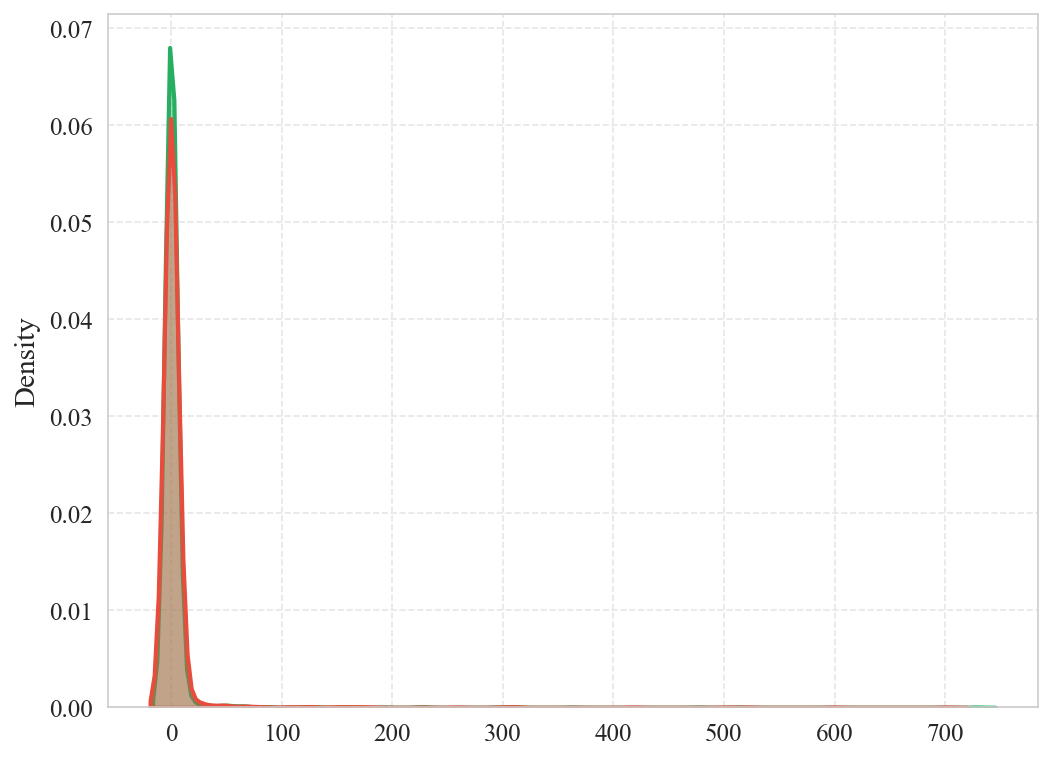

In [37]:
print("Mean violation score:")
print("  Secure:", secure_scores.mean())
print("  Vulnerable:", vuln_scores.mean())
print("  Δ:", delta_scores.mean())
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=150)
sns.kdeplot(secure_scores, color='#27AE60', fill=True, alpha=0.4,
            label=f'Secure (n={len(secure_scores)})', linewidth=2)
sns.kdeplot(vuln_scores, color='#E74C3C', fill=True, alpha=0.4,
            label=f'Vulnerable (n={len(vuln_scores)})', linewidth=2)



In [38]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(delta_scores)
print("Wilcoxon signed-rank p:", p)
p_pos = np.mean(delta_scores > 0)
print("P(Δ > 0):", p_pos)

Wilcoxon signed-rank p: 0.004083885070636835
P(Δ > 0): 0.0188527878058564


In [40]:
from sae_java_bug.evaluation.global_baselines import run_global_baselines
results, summary, latex = run_global_baselines(
    secure_activations_sae,
    vulnerable_activations_sae
)

Running Isolation Forest...
Running Local Outlier Factor...
Running One-Class SVM...
Running PCA Reconstruction Error...
Running Cosine Distance to Centroid...
Running Mahalanobis Distance...
GLOBAL ANOMALY DETECTION BASELINES - SUMMARY

Claim: Vulnerable code does NOT form a globally anomalous population.
Evidence: All methods should show AUROC ~ 0.5 and small effect sizes.

----------------------------------------------------------------------------------------------------
Method                         AUROC      Accuracy   Cohen d    KS stat    KS p-val     P(d>0)    
----------------------------------------------------------------------------------------------------
Isolation Forest               0.499      0.503      -0.000     0.011      9.99e-01     0.346     
Local Outlier Factor           0.514      0.519      -0.001     0.045      1.43e-02     0.487     
One-Class SVM                  0.502      0.508      0.010      0.045      1.30e-02     0.538     
PCA Reconstruction Erro

In [ ]:
from sae_java_bug.evaluation.ablations import run_ablation_study

results, summary, latex = run_ablation_study(
    secure_activations_sae,
    vulnerable_activations_sae,
    # tau_values=[0.99, 0.995, 0.999],
    # min_support_values=[50],
    # scoring_methods=['weighted']
)
print(summary)
print(latex)


Ablation sweep: 100%|██████████| 48/48 [1:35:41<00:00, 119.61s/it]  

INVARIANT ABLATION STUDY - SUMMARY

tau      min_sup    method       #inv       P(d>0)     AUROC      Mean d       Wilcox p    
------------------------------------------------------------------------------------------------------------------------
0.900    50         weighted     19926      0.070      0.502      3.4465       1.69e-01   
0.900    50         unweighted   19926      0.067      0.502      0.8492       2.07e-01   
0.900    100        weighted     15127      0.066      0.502      3.0837       1.76e-01   
0.900    50         max          19926      0.065      0.503      0.0859       6.31e-04   *
0.900    100        unweighted   15127      0.064      0.502      0.8039       1.90e-01   
0.900    100        max          15127      0.062      0.503      0.0712       3.38e-03   *
0.950    50         weighted     18470      0.061      0.501      2.6500       1.88e-01   
0.950    50         max          18470      0.059      0.502      0.0836       4.13e-04   *
0.950    100        